In [2]:
import torch
import torch.nn.functional as F
import IPython.display as ipd
import matplotlib.pyplot as plt

In [3]:
# models the equation: x(t) = A(t)sin(2*pi*f(t)+phi_0)
def sinusoid(
    amplitude: torch.Tensor,  # Amplitude (batch_size, n_frames)
    frequency: torch.Tensor,  # Angular frequency (batch_size, n_frames)
    n_samples: int,  # Number of samples to generate (will upsample to this)
    phase: torch.Tensor = None,  # Initial phase (batch_size,), if None then 0
) -> torch.Tensor:
    if phase is None: 
        phase=torch.zeros(frequency.shape[0])
    # must upsample to n_samples if needed
    if frequency.shape[1]<n_samples:
        amplitude = F.interpolate(amplitude.unsqueeze(0),n_samples,mode='linear')
        frequency= F.interpolate(frequency.unsqueeze(0),n_samples,mode='linear')
    amplitude=amplitude.squeeze(0)
    frequency=frequency.squeeze(0) #(5,16000)
    # phi(t) = phi_0 + 2*pi*f(t)
    phase=phase.unsqueeze(-1) # adds a dimension in the end (eg: (5,1))
    # print("phase shape: ", phase.shape)
    # print("freq shape: ", frequency.shape)
    frequency = torch.cat([phase,frequency],dim=1)[:,:-1] #5,16001 (with phase added at the front)
    phase=torch.cumsum(frequency,dim=1)
    return amplitude*torch.sin(phase)
    

In [4]:
sample_rate=16000
f0=440
frame_rate=100
n=5
frequency = torch.linspace(f0,f0/2,frame_rate).unsqueeze(0)
frequency = frequency * 2 * torch.pi / sample_rate
amplitude=torch.linspace(0,1,frame_rate).unsqueeze(0)
print(amplitude.shape)
# amplitude = torch.ones(1, frame_rate) * 0.5
# print(amplitude.shape)
y = sinusoid(amplitude, frequency, n_samples=sample_rate)
ipd.Audio(y[0].numpy(), rate=sample_rate, normalize=False)


torch.Size([1, 100])


In [5]:
torch.random.manual_seed(0)
rand_amp = torch.rand(1, frame_rate)

y_hat = sinusoid(rand_amp, frequency, n_samples=sample_rate)

ipd.Audio(y_hat[0].numpy(), rate=sample_rate, normalize=False)

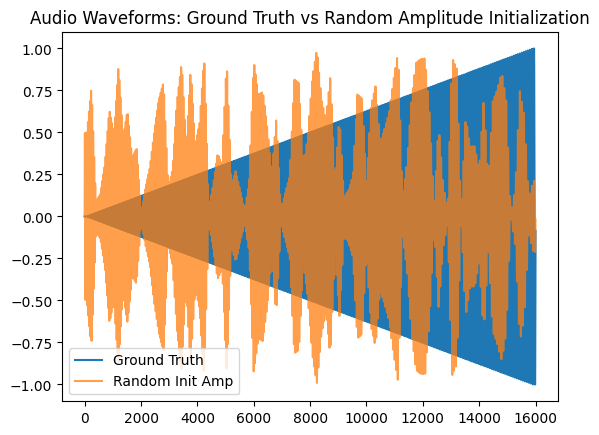

In [6]:
plt.plot(y[0].numpy(), label="Ground Truth")
plt.plot(y_hat[0].numpy(), alpha=0.75, label="Random Init Amp")
plt.legend()
plt.title("Audio Waveforms: Ground Truth vs Random Amplitude Initialization")
plt.show()

In [7]:
amp_param=torch.nn.Parameter(y_hat)
optimiser = torch.optim.Adam([amp_param]) # error if no brackets
loss_log=[]
for i in range(1000):
    # forward pass
    y_hat=sinusoid(amp_param,frequency,n_samples=sample_rate)
    loss = F.l1_loss(y_hat, y)
    loss_log.append(loss.item())
    # backward pass
    optimiser.zero_grad()
    loss.backward()
    optimiser.step()
        

    

In [8]:
# now we recreate the audio sample with the optimised amplitude 
y_hat = sinusoid(amp_param, frequency, n_samples=sample_rate)
ipd.Audio(y_hat[0].detach().numpy(), rate=sample_rate, normalize=True) # detach from the computation graph



In [9]:
def additive_synth(
    amplitudes: torch.Tensor,  # Amplitudes (batch, n_sinusoids, n_frames)
    frequencies: torch.Tensor,  # Angular frequencies (batch, n_sinusoids, n_frames)
    n_samples: int,  # Number of samples to generate (upsample from n_frames)
):
    # upsample
    amplitudes=F.interpolate(amplitudes,n_samples,mode='linear')
    frequencies=F.interpolate(frequencies,n_samples,mode='linear')
    
    phase = torch.zeros(frequencies[...,:1].shape)
    # append this to the frequencies list 
    frequencies=torch.cat((phase,frequencies),dim=-1) # stack along column
    # now using the relation phase(n)= initial phase + sum(frequencies)
    phase = torch.cumsum(frequencies, dim=-1)[..., :-1]
    y=amplitudes*torch.sin(phase)
    y=torch.sum(y,dim=1)
    return y
    

In [10]:
# create a dummy input signal.. lets create a wave that goes to a target frequenccy and then increases back

freq_list=torch.rand(10)*500+200
sample_rate = 16000 # Hx
frame_rate = 100
target_frequency = 440
frequencies=[]
for freq in freq_list:
    half=torch.linspace(freq,target_frequency,frame_rate)
    half_rev=half.flip(-1)
    full=torch.cat((half,half_rev))
    frequencies.append(full)

frequencies_t=torch.stack(frequencies,dim=0).unsqueeze(0) #(10,200)
# conver to angular frequency with the formula: omega = 2*pi*f/F 
frequencies_t = frequencies_t*2*torch.pi/sample_rate
amplitudes = torch.ones(1, frequencies_t.shape[1], frequencies_t.shape[-1])
print(amplitudes)
time=frequencies_t.shape[-1]/frame_rate
num_samples = int(time*sample_rate)
print(num_samples)
y=additive_synth(amplitudes,frequencies_t,n_samples=int(num_samples))
ipd.Audio(y[0].numpy(), rate=sample_rate)
    

tensor([[[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]]])
32000


In [ ]:
# harmonic synth: instead of having any freqency, we only have multiples of a fundamental frequency. This is a constrained version of the above

sample_rate = 16000
frame_rate = 100
n_harmonics = 16  
f0 = 110
fundamental = torch.ones((1, frame_rate)) * f0
fundamental = 2 * torch.pi * fundamental / sample_rate


def get_harmonic_frequencies(
    f0: torch.Tensor,  # Fundamental frequency (Hz) (batch, n_frames)
    n_harmonics: int,  # Number of harmonics to generate
):
    rows=[]
    # for each frequency, we need to add n_harmonics rows downwards
    for h in range(1,n_harmonics+1):
        row = f0*h
        rows.append(row)
    frequencies=torch.stack(rows,dim=1)
    
    return frequencies

def harmonic_synth(
    f0: torch.Tensor,  # Fundamental frequency (Hz) (batch, n_frames)
    harmonic_amps: torch.Tensor,  # Amplitudes of harmonics (batch, n_harmonics, n_frames)
    n_samples: int,  # Number of samples to generate (upsample from n_frames)
):
    # Create the harmonic frequency envelopes
    n_harmonics = harmonic_amps.shape[1]
    frequencies = get_harmonic_frequencies(f0, n_harmonics) 
    return additive_synth(harmonic_amps, frequencies, n_samples=n_samples)

# now get random aplitudes that sum to one for each frequency 

def random_harmonic_amps(
    batch_size: int,  # Number of samples to generate
    n_harmonics: int,  # Number of harmonics to generate
    n_frames: int,  # Number of frames in length
):
    amps = torch.rand((batch_size,n_harmonics))*40 -40 #(in the range -40 to 0)
    # bring to linear scale 
    amps = torch.pow(10,amps/20.0)
    # normalise to 1 
    amps = amps / amps.sum(dim=1, keepdim=True)
    # strech to n_frames
    amps=amps.unsqueeze(-1).expand(-1,-1,n_frames)
    return amps


y = []
for i in range(10):
    harmonic_amps = random_harmonic_amps(1, n_harmonics, frame_rate)
    y.append(harmonic_synth(fundamental, harmonic_amps, n_samples=sample_rate))

y = torch.cat(y, dim=1)
ipd.Audio(y[0].numpy(), rate=sample_rate)

torch.Size([1, 16, 16000])
in get_harmonic frequencies: torch.Size([16, 1, 100])


RuntimeError: stack expects each tensor to be equal size, but got [1, 100] at entry 0 and [16, 1, 100] at entry 1